# Detecting arrythmia using Deep Leaning

## Loading modules

In [1]:
import pandas as pd
import numpy as np
import wfdb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, TimeDistributed
from tensorflow.keras.optimizers import Adam

## Download Dataset

In [3]:
from pathlib import Path
import zipfile

database_filename = "mit-bih-arrhythmia-database-1.0.0.zip"
expected_file = Path("mit-bih-arrhythmia-database-1.0.0")

if not expected_file.exists():
    with zipfile.ZipFile(database_filename, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extraction complete.")
else:
    print("Files already extracted.")

Files already extracted.


## Loading data

Loading list of records available, from dataset available [here](https://physionet.org/content/mitdb/1.0.0/)

In [4]:
records = np.loadtxt("mit-bih-arrhythmia-database-1.0.0/RECORDS", dtype=int)

Defining invalid beats as well as abnormal beats, according to [Physiobank](https://archive.physionet.org/physiobank/annotations.shtml)

In [5]:
invalid_beat = [
    "[", "!", "]", "x", "(", ")", "p", "t", 
    "u", "`", "'", "^", "|", "~", "+", "s", 
    "T", "*", "D", "=", '"', "@"
]

abnormal_beats = [
    "L", "R", "B", "A", "a", "J", "S", "V", 
    "r", "F", "e", "j", "n", "E", "/", "f", "Q", "?"
]

## Processing dataset

This function classify a beat according to its symbol and the list provided above.

In [6]:
def classify_beat(symbol):
    if symbol in abnormal_beats:
        return 1
    elif symbol == "N" or symbol == ".":
        return 0    

Given a signal, the beat location, and the window to be used as a sequence, this function gets the sequence. It will return an empty array in case of an invalid beat or empty sequence.

In [7]:
def get_sequence(signal, beat_loc, window_sec, fs):
    window_one_side = window_sec * fs
    beat_start = beat_loc - window_one_side
    beat_end = beat_loc + window_one_side
    if beat_end < signal.shape[0]:
        sequence = signal[beat_start:beat_end, 0]
        return sequence.reshape(1, -1, 1)
    else:
        return np.array([])

The code below will build a list of labels and sequences as well as map the sequences for each patient. The percentage calculated represents the ratio of abnormal beats in each patient data.

In [8]:
all_sequences = []
all_labels = []
window_sec = 3
subject_map = []
for subject in records:
    record = wfdb.rdrecord(f'mit-bih-arrhythmia-database-1.0.0/{subject}')
    annotation = wfdb.rdann(f'mit-bih-arrhythmia-database-1.0.0/{subject}', 'atr')
    atr_symbol = annotation.symbol
    atr_sample = annotation.sample
    fs = record.fs
    scaler = StandardScaler()
    signal = scaler.fit_transform(record.p_signal)
    subject_labels = []
    for i, i_sample in enumerate(atr_sample):
        label = classify_beat(atr_symbol[i])
        sequence = get_sequence(signal, i_sample, window_sec, fs)
        if label is not None and sequence.size > 0:
            all_sequences.append(sequence)
            subject_labels.append(label)

    normal_percentage = sum(subject_labels) / len(subject_labels)
    subject_map.append({
        "subject": subject,
        "percentage": normal_percentage,
        "num_seq": len(subject_labels),
        "start": len(all_labels),
        "end": len(all_labels)+len(subject_labels)
    })
    all_labels.extend(subject_labels)

In [9]:
print(subject_map[:5])

[{'subject': 100, 'percentage': 0.014997794441993825, 'num_seq': 2267, 'start': 0, 'end': 2267}, {'subject': 101, 'percentage': 0.002688172043010753, 'num_seq': 1860, 'start': 2267, 'end': 4127}, {'subject': 102, 'percentage': 0.9546287809349221, 'num_seq': 2182, 'start': 4127, 'end': 6309}, {'subject': 103, 'percentage': 0.0009615384615384616, 'num_seq': 2080, 'start': 6309, 'end': 8389}, {'subject': 104, 'percentage': 0.9266756635177688, 'num_seq': 2223, 'start': 8389, 'end': 10612}]


Creating bins to be used to stratify the train and validation split. 

In [10]:
subject_map = pd.DataFrame(subject_map)

In [11]:
print(subject_map[:5])

   subject  percentage  num_seq  start    end
0      100    0.014998     2267      0   2267
1      101    0.002688     1860   2267   4127
2      102    0.954629     2182   4127   6309
3      103    0.000962     2080   6309   8389
4      104    0.926676     2223   8389  10612


The code presented will create class in each patient is segmented.

In [12]:
bins = [0, 0.2, 0.6, 1.0]
subject_map["bin"] = pd.cut(subject_map['percentage'], bins=bins, labels=False, include_lowest=True)

In [13]:
print(subject_map[:5])

   subject  percentage  num_seq  start    end  bin
0      100    0.014998     2267      0   2267    0
1      101    0.002688     1860   2267   4127    0
2      102    0.954629     2182   4127   6309    2
3      103    0.000962     2080   6309   8389    0
4      104    0.926676     2223   8389  10612    2


Now, the dataset is split into train and validation, stratifying by the bin defined above.

In [14]:
train, validation = train_test_split(subject_map, test_size=0.25, stratify=subject_map["bin"], random_state=42)

This function build a dataset based on the map for each split.

In [15]:
def build_dataset(df, all_sequences, all_labels):
    sequences = []
    labels = []
    for i, row in df.iterrows():
        start = int(row["start"])
        end = int(row["end"])
        sequences.extend(all_sequences[start:end])
        labels.extend(all_labels[start:end])
        
    return np.vstack(sequences), np.vstack(labels)

In [16]:
X_train, y_train = build_dataset(train, all_sequences, all_labels)
X_val, y_val = build_dataset(validation, all_sequences, all_labels)

In [17]:
X_train.shape, y_train.shape

((82964, 1440, 1), (82964, 1))

## Training the model

### CNN model

In [18]:
from tensorflow.keras.layers import Input, Flatten, MaxPooling1D, Dropout
from tensorflow.keras.models import Model
from qkeras import QConv1D, QActivation, QDense
from tensorflow.keras.optimizers import Adam

sequence_size = X_train.shape[1]
n_features = 1

inputs = Input(shape=(sequence_size, n_features))

# Quantized Conv1D
x = QConv1D(
    filters=16,
    kernel_size=4,
    strides=1,
    padding="same",
    kernel_quantizer="quantized_bits(2,0,alpha=1)",
    bias_quantizer="quantized_bits(2,0,alpha=1)",
    name="qconv1d"
)(inputs)
x = QActivation('quantized_relu(2,0)', name="qact_conv")(x)
x = MaxPooling1D(pool_size=4, name="maxpool")(x)
x = Flatten(name="flatten")(x)
x = Dropout(0.5, name="dropout")(x)

# Quantized Dense
x = QDense(
    1,
    kernel_quantizer="quantized_bits(2,0,alpha=1)",
    bias_quantizer="quantized_bits(2,0,alpha=1)",
    name="qdense"
)(x)
outputs = QActivation('quantized_sigmoid(2)', name="qact_output")(x)

cnn_model = Model(inputs=inputs, outputs=outputs, name="quantized_cnn")

optimizer = Adam(learning_rate=0.001)
cnn_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

# Print the quantized layers
from qkeras.autoqkeras.utils import print_qmodel_summary

print_qmodel_summary(cnn_model)

Model: "quantized_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1440, 1)]         0         
                                                                 
 qconv1d (QConv1D)           (None, 1440, 16)          80        
                                                                 
 qact_conv (QActivation)     (None, 1440, 16)          0         
                                                                 
 maxpool (MaxPooling1D)      (None, 360, 16)           0         
                                                                 
 flatten (Flatten)           (None, 5760)              0         
                                                                 
 dropout (Dropout)           (None, 5760)              0         
                                                                 
 qdense (QDense)             (None, 1)               

/home/fotis/anaconda3/envs/arrhythmia/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [19]:
import json
from tensorflow.keras.models import load_model

train = True
if train:
    hist_cnn = cnn_model.fit(
        X_train, 
        y_train, 
        batch_size=128,
        epochs=15,
        validation_data=(X_val, y_val)
    )
    cnn_model.save('QKeras_Model4_2bits/cnn_model.keras')

    with open('QKeras_Model4_2bits/hist_cnn.json', 'w') as f:
        json.dump(hist_cnn.history, f)

    with open('QKeras_Model4_2bits/hist_cnn.json', 'r') as f:
        hist_cnn = json.load(f)
else:
    cnn_model = load_model('QKeras_Model4_2bits/cnn_model.keras')

    with open('QKeras_Model4_2bits/hist_cnn.json', 'r') as f:
        hist_cnn = json.load(f)

Epoch 1/15
649/649 [==============================] - 12s 18ms/step - loss: 3.7197 - accuracy: 0.7207 - val_loss: 3.0778 - val_accuracy: 0.7627
Epoch 2/15
649/649 [==============================] - 13s 20ms/step - loss: 1.7427 - accuracy: 0.8340 - val_loss: 2.4443 - val_accuracy: 0.7626
Epoch 3/15
649/649 [==============================] - 14s 21ms/step - loss: 1.1616 - accuracy: 0.8793 - val_loss: 1.9220 - val_accuracy: 0.7222
Epoch 4/15
649/649 [==============================] - 13s 19ms/step - loss: 0.9556 - accuracy: 0.8931 - val_loss: 1.9755 - val_accuracy: 0.7654
Epoch 5/15
649/649 [==============================] - 12s 18ms/step - loss: 0.9889 - accuracy: 0.8969 - val_loss: 2.2063 - val_accuracy: 0.7457
Epoch 6/15
649/649 [==============================] - 11s 17ms/step - loss: 0.9007 - accuracy: 0.9056 - val_loss: 2.2383 - val_accuracy: 0.7800
Epoch 7/15
649/649 [==============================] - 12s 18ms/step - loss: 0.8590 - accuracy: 0.9089 - val_loss: 1.8943 - val_accuracy:

/home/fotis/anaconda3/envs/arrhythmia/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


In [20]:
cnn_model.evaluate(X_val, y_val)

822/822 [==============================] - 2s 2ms/step - loss: 2.0297 - accuracy: 0.7863


[2.029651165008545, 0.7863121032714844]

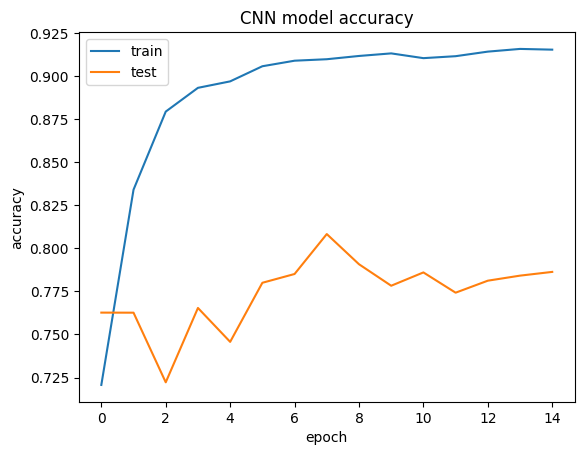

In [21]:
# summarize history for accuracy
plt.plot(hist_cnn['accuracy'])
plt.plot(hist_cnn['val_accuracy'])
plt.title('CNN model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

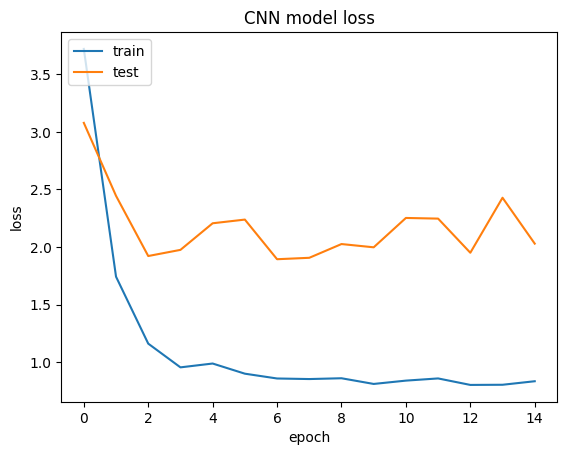

In [22]:
# summarize history for loss
plt.plot(hist_cnn['loss'])
plt.plot(hist_cnn['val_loss'])
plt.title('CNN model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## Make an hls4ml config & model

In [23]:
import hls4ml
import plotting 

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

config = hls4ml.utils.config_from_keras_model(cnn_model, granularity='name', backend='Vitis')
config['Model']['ReuseFactor'] = 1
config['Model']['Precision'] = 'ap_fixed<16,6>'
print("-----------------------------------")
print("Configuration")
plotting.print_dict(config)
print("-----------------------------------")
hls_model = hls4ml.converters.convert_from_keras_model(cnn_model, hls_config=config, backend='Vitis', output_dir='hls4ml/QKeras_model_4_2bits', part='xcu250-figd2104-2L-e', io_type='io_stream')

Interpreting Model
Topology:
Layer name: input_1, layer type: InputLayer, input shapes: [[None, 1440, 1]], output shape: [None, 1440, 1]
Layer name: qconv1d, layer type: QConv1D, input shapes: [[None, 1440, 1]], output shape: [None, 1440, 16]
Layer name: qact_conv, layer type: Activation, input shapes: [[None, 1440, 16]], output shape: [None, 1440, 16]
Layer name: maxpool, layer type: MaxPooling1D, input shapes: [[None, 1440, 16]], output shape: [None, 360, 16]
Layer name: flatten, layer type: Reshape, input shapes: [[None, 360, 16]], output shape: [None, 5760]
Layer name: qdense, layer type: QDense, input shapes: [[None, 5760]], output shape: [None, 1]
Layer name: qact_output, layer type: HardActivation, input shapes: [[None, 1]], output shape: [None, 1]
-----------------------------------
Configuration
Model
  Precision:         ap_fixed<16,6>
  ReuseFactor:       1
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
LayerName
  input_1
    Trace: 

/home/fotis/anaconda3/envs/arrhythmia/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


## Visualise the model architecture

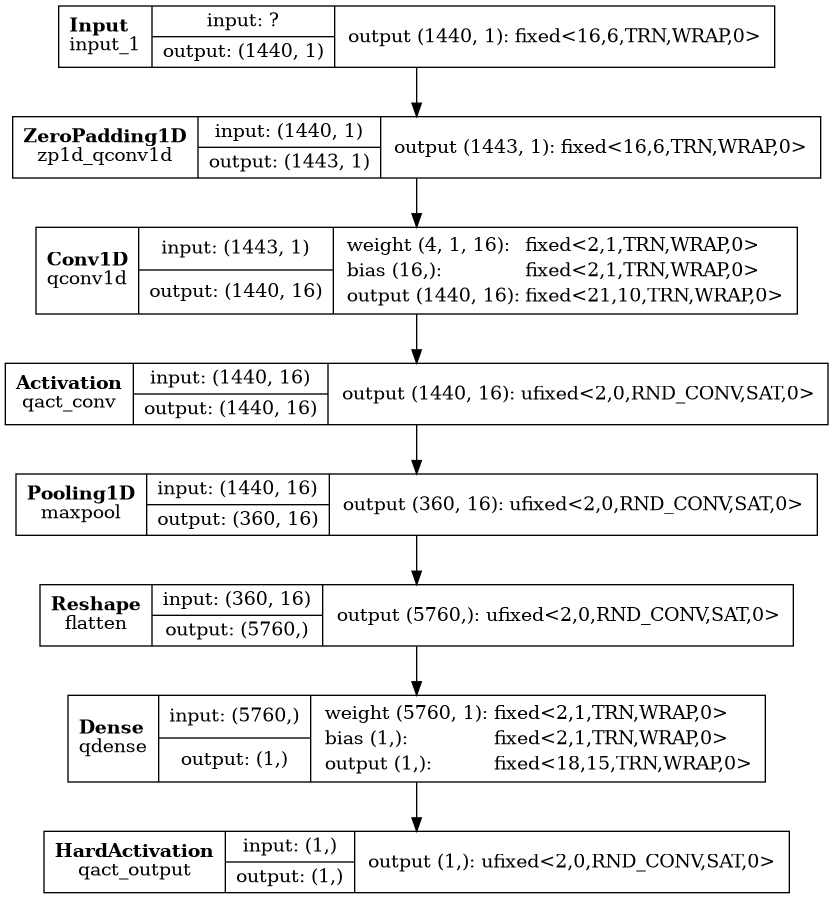

In [24]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

## Compile, predict

In [25]:
hls_model.compile()
X_val = np.ascontiguousarray(X_val)
y_hls = hls_model.predict(X_val)

/home/fotis/anaconda3/envs/arrhythmia/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


Writing HLS project
Done


## HLS4ML Model Accuracy

In [26]:
from sklearn.metrics import accuracy_score

# Convert predictions to binary labels using a threshold of 0.5
y_hls_pred   = (y_hls > 0.5).astype(int)

# Calculate accuracy using ground truth y_val
acc_hls   = accuracy_score(y_val, y_hls_pred)

print("HLS4ML Model Accuracy: {:.2f}%".format(acc_hls * 100))


HLS4ML Model Accuracy: 78.61%


## Synthesize

In [27]:
hls_model.build(csim=False, synth=True, vsynth=True, export=True)


****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
  **** SW Build 4023990 on Oct 11 2023
  **** IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
  **** SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2023.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vitis_HLS/2023.2/bin/unwrapped/lnx64.o/vitis_hls'
INFO: [HLS 200-10] For user 'fotis' on host 'fotis-Z390-UD' (Linux_x86_64 version 6.8.0-64-generic) on Mon Jul 21 15:31:00 EEST 2025
INFO: [HLS 200-10] On os Ubuntu 24.04.2 LTS
INFO: [HLS 200-10] In directory '/home/fotis/arrhythmia-detection/hls4ml/QKeras_model_4_2bits'
INFO: [HLS 200-2053] The vitis_hls executable is being deprecated. Consider using vitis-run --mode hls --tcl
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-1510] Running: open_proj

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.491',
  'BestLatency': '2898',
  'WorstLatency': '2898',
  'IntervalMin': '2890',
  'IntervalMax': '2890',
  'BRAM_18K': '18',
  'FF': '8097',
  'LUT': '22668',
  'DSP': '0',
  'URAM': '0',
  'AvailableBRAM_18K': '5376',
  'AvailableDSP': '12288',
  'AvailableFF': '3456000',
  'AvailableLUT': '1728000',
  'AvailableURAM': '1280'},
 'VivadoSynthReport': {'LUT': '4796',
  'FF': '5567',
  'BRAM_18K': '3.5',
  'URAM': '5',
  'DSP48E': '0'}}

## Check the reports

In [28]:
hls4ml.report.read_vivado_report('hls4ml/QKeras_model_4_2bits/')

Found 1 solution(s) in hls4ml/QKeras_model_4_2bits//myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Mon Jul 21 15:34:21 2025

* Version:        2023.2 (Build 4023990 on Oct 11 2023)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcu250-figd2104-2L-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.491 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+-----------+-----------+------+------+----------+
    |  Latency (cycles) |   Latency (absolute)  |   Interval  | Pipeline |
    |   min   |   max   |    min    |    max    |  min |  max |   Type   |
    +--